# 05 — Modal Analysis (smoothed detection + shaker input bias)

Each dataset is treated as one doubly-clamped span: find transverse
resonances, extract complex mode shapes $(\varphi_y, \varphi_z)$, compare to
the clamped–clamped Euler–Bernoulli modes via the **MAC**, classify the
polarization — and now also **quantify the shaker's off-axis input** so
shaker-borne spectral peaks are not misread as cable resonances.

### What changed vs the old notebook
- The detection fingerprint uses **Welch-averaged spectra** by default
  (Δf = 0.5 Hz, ~11 averages) — the averaging smooths the bin-to-bin
  fluctuations that produced spurious `find_peaks` detections. An extra
  boxcar smoothing (`SMOOTH_HZ`) and the raw-FFT mode remain available.
- `NORMALIZE_BY_INPUT=True` divides the detection signal by the shaker-head
  input power spectrum → peaks that only mirror the excitation flatten out.
- `plot_shaker_directionality` shows |V_x|, |V_y|, |V_z| on the shaker head
  and the per-frequency power fractions next to the detected resonances.

| § | Content |
|---|---|
| 1 | Setup & parameters |
| 2 | Fingerprint & resonance detection (smoothed) |
| 3 | Shaker input bias: directionality + input-normalized detection |
| 4 | MAC vs Euler–Bernoulli modes |
| 5 | Polarization summary |
| 6 | Deep-dive, cross-dataset charts, dashboard |
| 7 | Export → `results/modal_summary.csv` / `.npz` |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Editable reload while iterating on the package
%load_ext autoreload
%autoreload 2

import ldv_analysis as la
from ldv_analysis import config, io, analysis, plotting, export

plt.rcParams.update({
    "font.size": 11, "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 120, "savefig.dpi": 300, "figure.autolayout": True,
    "axes.titlesize": 11, "axes.labelsize": 10, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "lines.linewidth": 1.2,
})
print(f"{len(la.ALL_DATASETS)} datasets in catalogue.")

46 datasets in catalogue.


---
## § 1  Setup & parameters

In [11]:
from ldv_analysis import modal, modal_plotting

ACTIVE_LABELS = [f"Cable{i}_10cm" for i in range(1, 8)]
# ACTIVE_LABELS = [f"Cable{i}_{gap}cm{('_Sag' if sag else '')}"
#                  for i in range(1, 8) for gap in [5, 10, 15]
#                  for sag in [False, True]]

# Detection / extraction parameters
F_MIN, F_MAX       = 5.0, 500.0
PEAK_PROMINENCE    = 0.08     # fraction of the strongest in-band peak
MIN_SPACING_HZ     = 10.0
POL_BW_FRAC        = 0.10     # mode-extraction bandpass f_n ± 10 %
N_THEORY_MODES     = 5

# Fingerprint construction (new)
FINGERPRINT_METHOD = 'welch'  # 'welch' (averaged, smooth) | 'fft' (raw)
SMOOTH_HZ          = 2.0      # extra boxcar smoothing [Hz], e.g. 2.0, or None
NORMALIZE_BY_INPUT = True    # divide detection signal by shaker input power

LIN_THRESH, CIRC_THRESH = 0.10, 0.80

DATASETS = config.select_datasets(ACTIVE_LABELS)
for cfg in DATASETS:
    io.load_cable_dataset(cfg, verbose=False)
print(f"{len(DATASETS)} dataset(s) loaded.")

7 dataset(s) loaded.


---
## § 2  Fingerprint & resonance detection

`modal.analyze_dataset` runs the full pipeline and stores everything in
`cfg['modal']`. The fingerprint plot is the tuning diagnostic for
`PEAK_PROMINENCE` / `MIN_SPACING_HZ` / `SMOOTH_HZ`.

In [12]:
for cfg in DATASETS:
    modal.analyze_dataset(
        cfg, f_min=F_MIN, f_max=F_MAX,
        prominence=PEAK_PROMINENCE, min_spacing_hz=MIN_SPACING_HZ,
        bw_frac=POL_BW_FRAC, n_theory_modes=N_THEORY_MODES,
        lin_thresh=LIN_THRESH, circ_thresh=CIRC_THRESH,
        fingerprint_method=FINGERPRINT_METHOD, smooth_hz=SMOOTH_HZ,
        normalize_by_input=NORMALIZE_BY_INPUT)

  [Cable1_10cm] 2 resonance(s): 489.0Hz(M1,line), 499.0Hz(M1,elli)
  [Cable2_10cm] 3 resonance(s): 5.0Hz(M5,line), 400.0Hz(M1,elli), 472.0Hz(M1,line)
  [Cable3_10cm] 5 resonance(s): 134.0Hz(M1,line), 161.0Hz(M1,line), 273.5Hz(M1,line), 386.0Hz(M2,line), 499.5Hz(M2,line)
  [Cable4_10cm] 3 resonance(s): 120.0Hz(M1,line), 161.0Hz(M1,line), 486.0Hz(M2,elli)
  [Cable5_10cm] 5 resonance(s): 111.5Hz(M1,line), 162.5Hz(M1,elli), 181.0Hz(M1,line), 265.0Hz(M1,elli), 499.5Hz(M2,elli)
  [Cable6_10cm] 3 resonance(s): 190.0Hz(M1,line), 489.5Hz(M1,line), 500.0Hz(M1,elli)
  [Cable7_10cm] 3 resonance(s): 96.0Hz(M1,line), 482.0Hz(M1,elli), 492.5Hz(M1,elli)


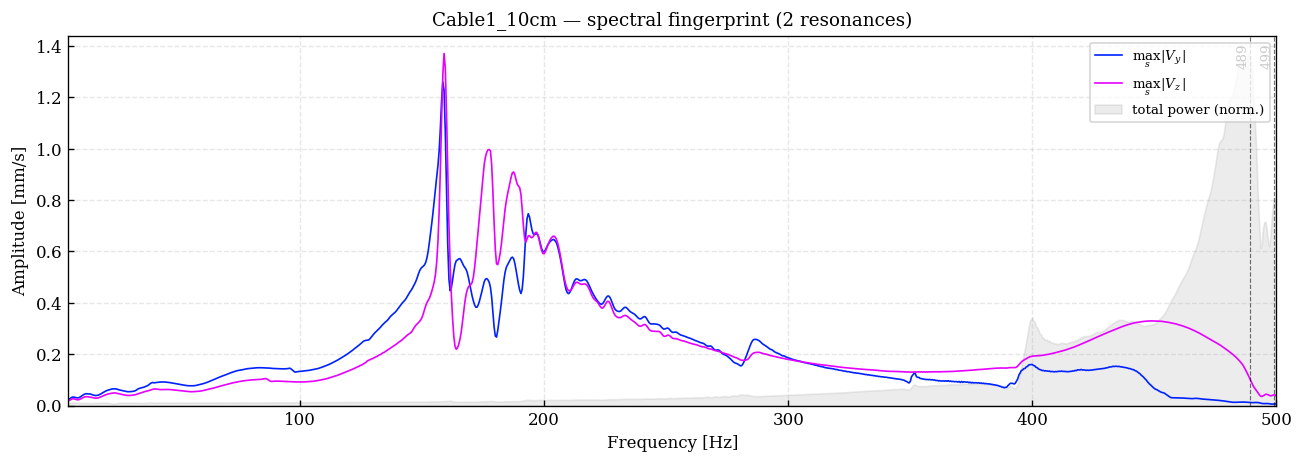

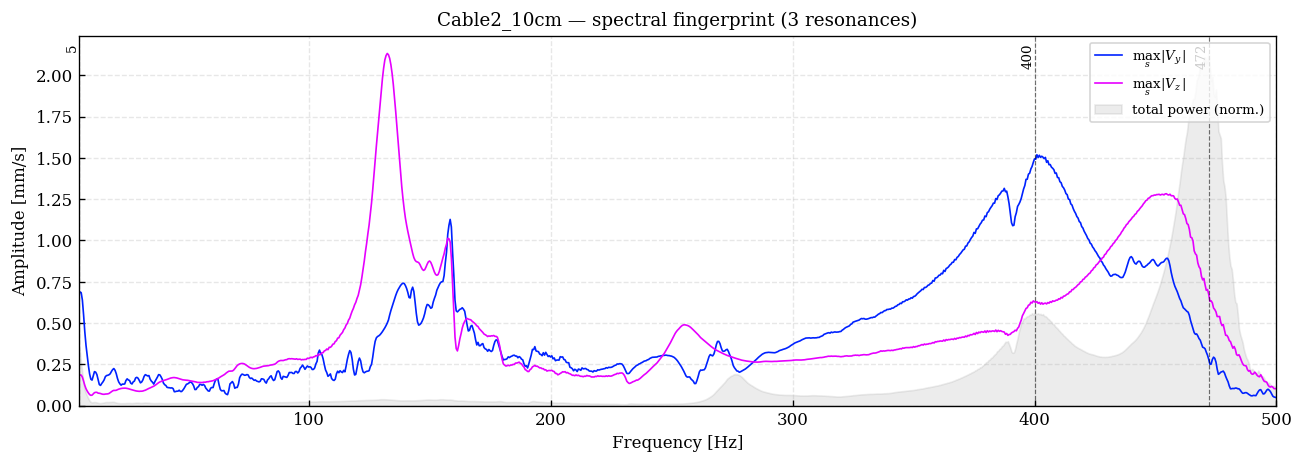

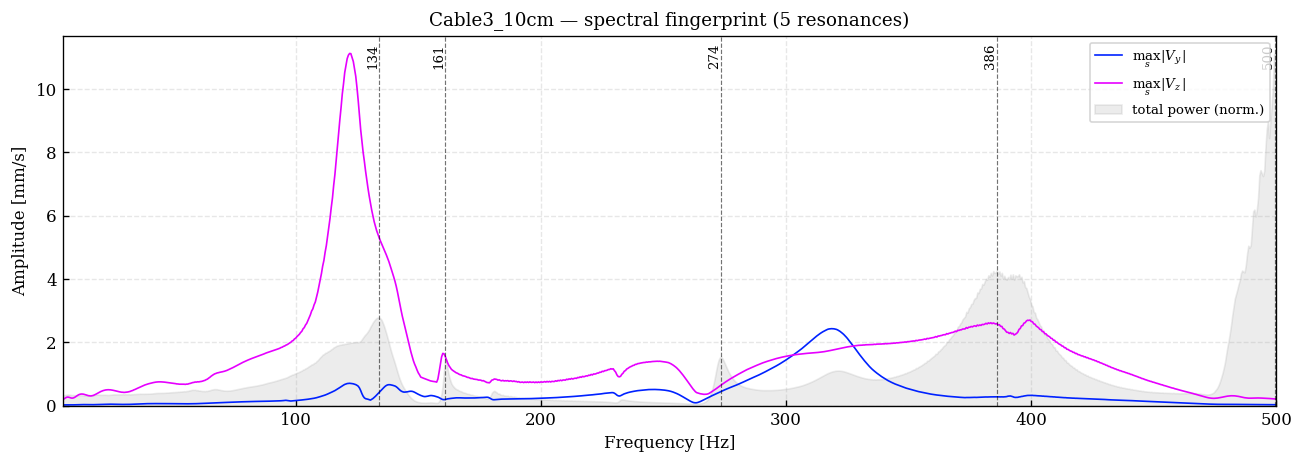

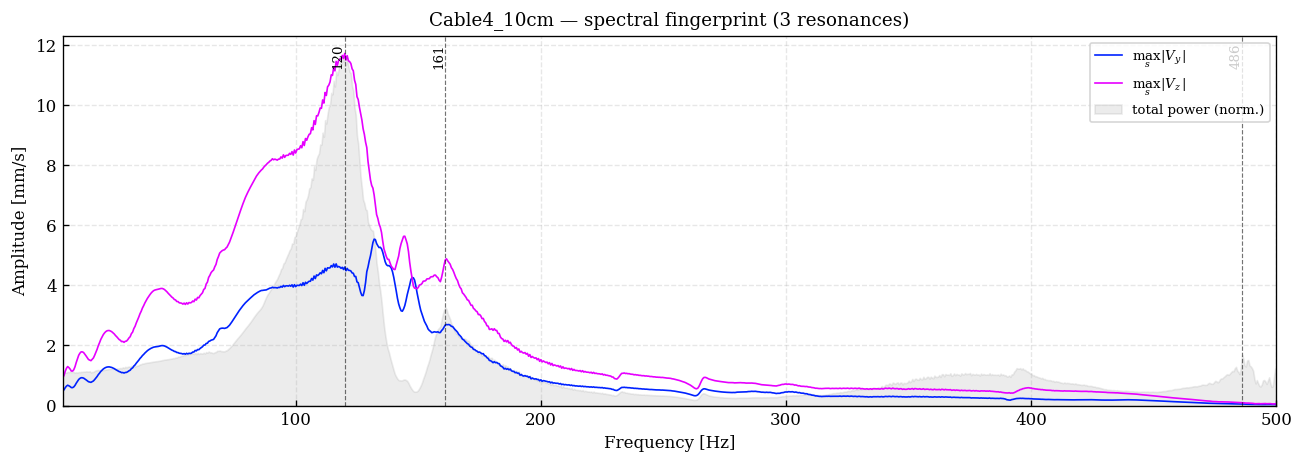

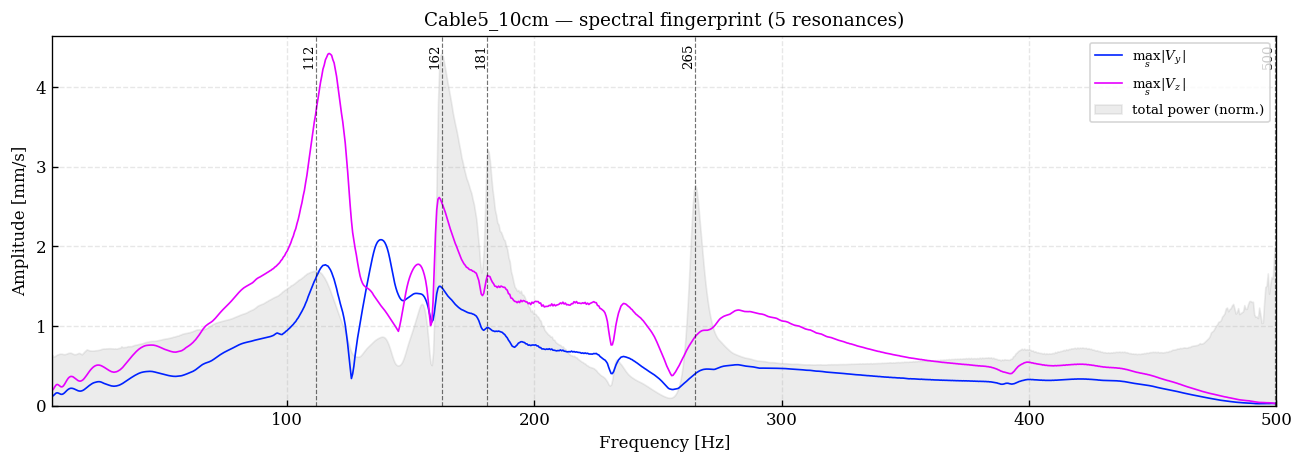

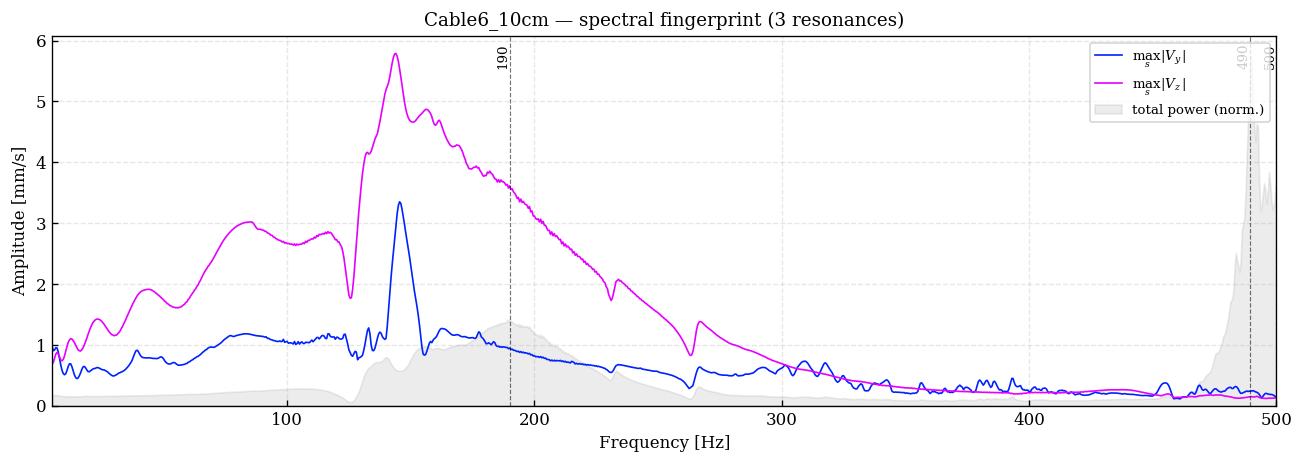

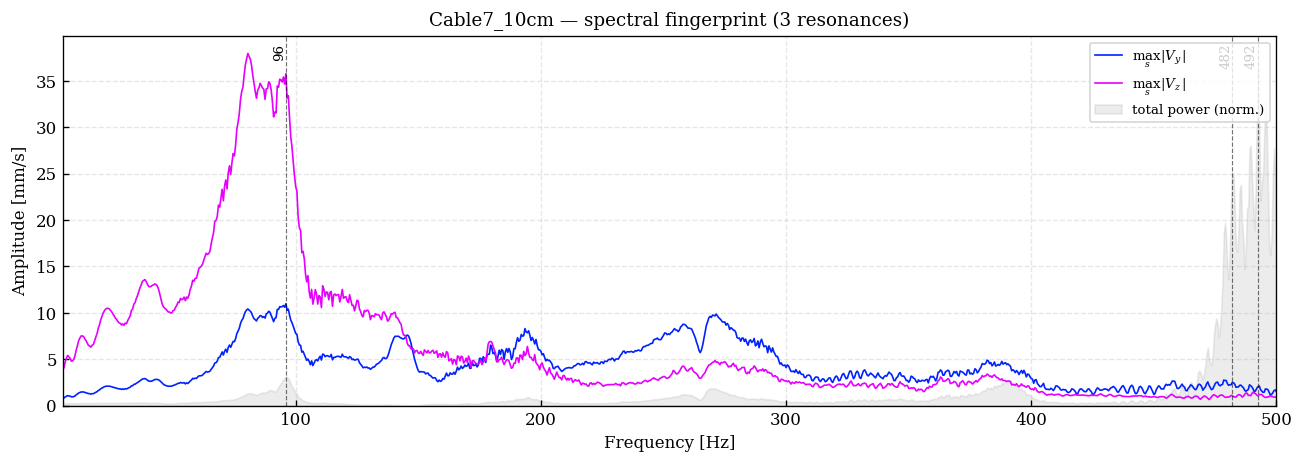

In [13]:
for cfg in DATASETS:
    modal_plotting.plot_fingerprint(cfg)
    plt.show()

---
## § 3  Shaker input bias

**Suspicion:** several detected "resonances" sit at similar frequencies across
very different cables, well below the clamped-beam predictions — consistent
with the shaker exciting transverse (y/z) motion at specific frequencies
rather than the cable resonating.

Diagnostics:
1. `plot_shaker_directionality` — shaker-head spectra + per-frequency power
   fractions next to the cable detection signal. Detected peaks that coincide
   with off-axis input bands are suspect.
2. Detection with `normalize_by_input=True` — peaks surviving the
   normalization are genuine output-to-input amplifications (resonances);
   peaks that vanish were input coloration.

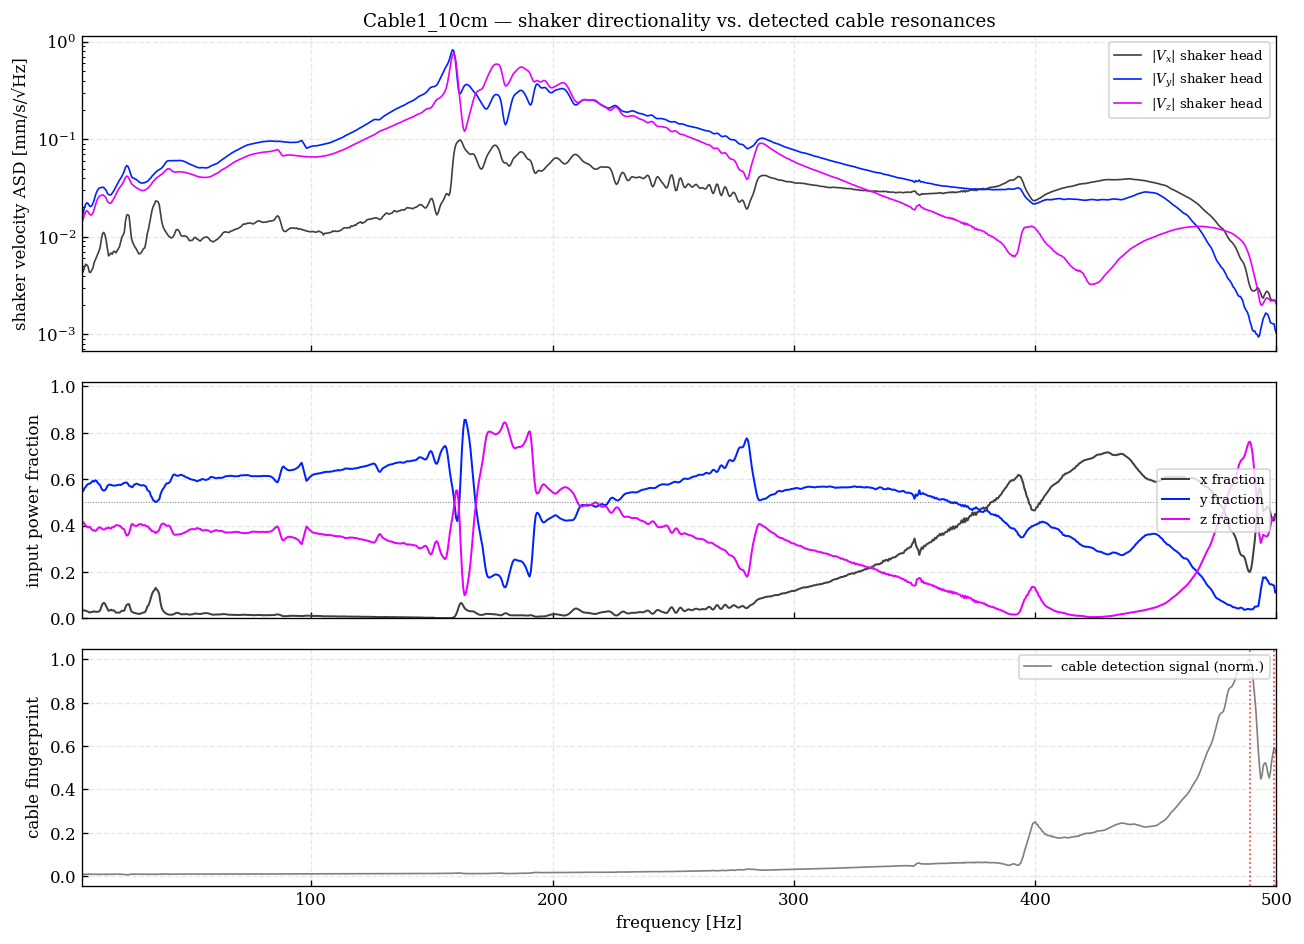

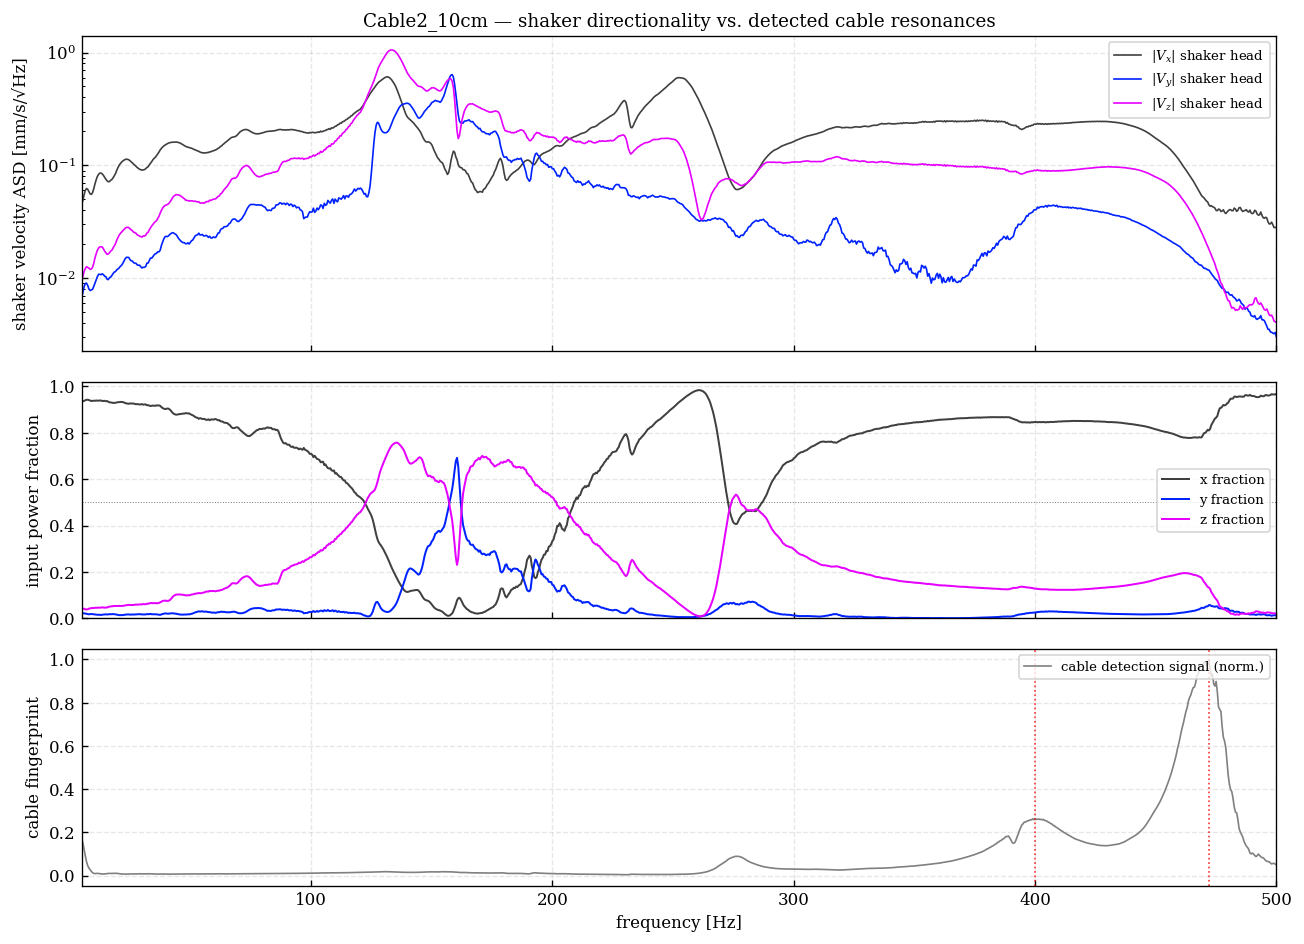

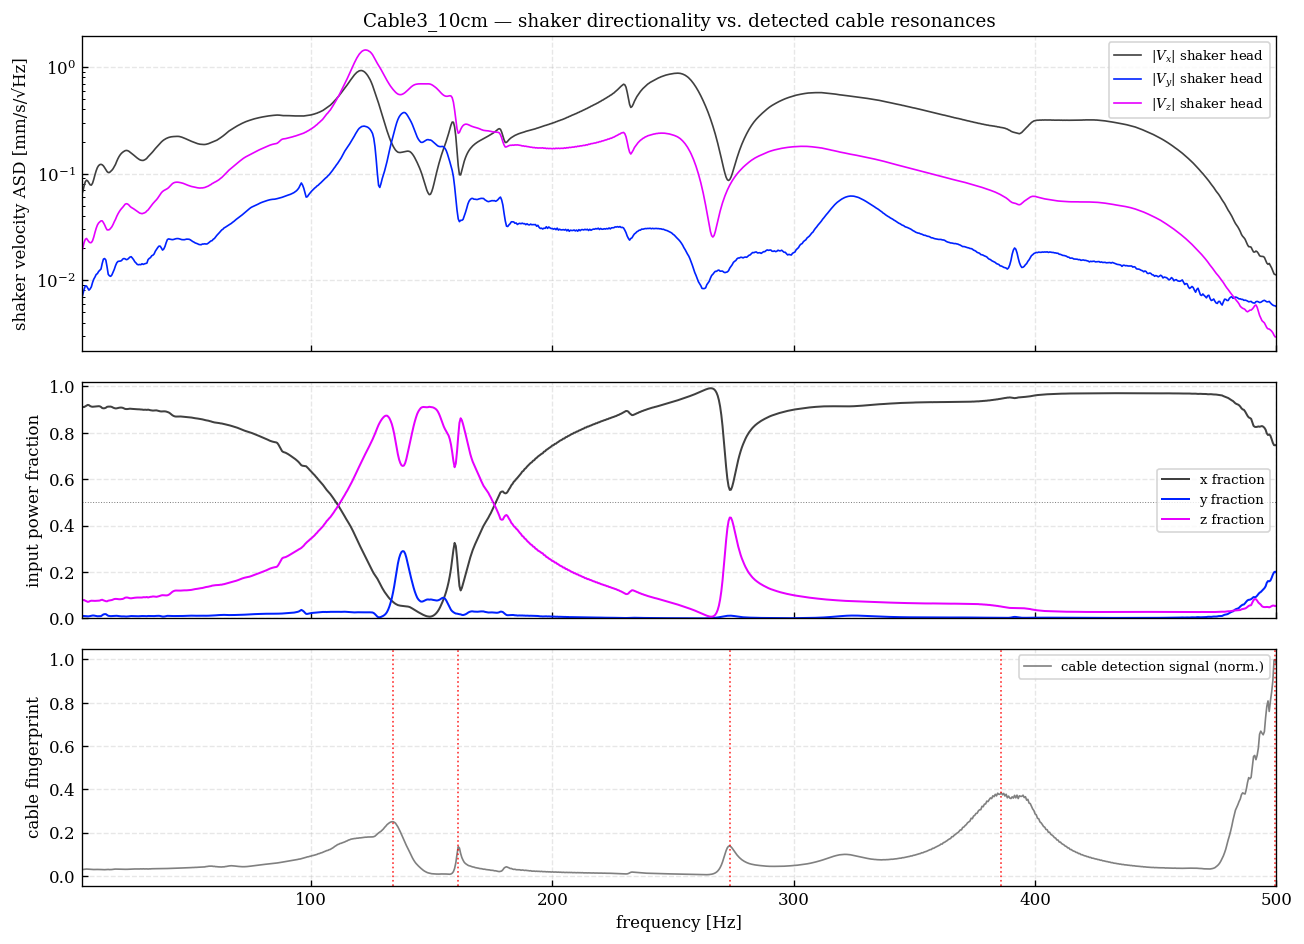

In [14]:
for cfg in DATASETS[:3]:          # edit the slice
    modal_plotting.plot_shaker_directionality(cfg)
    plt.show()

In [15]:
# Raw vs input-normalized detection, per dataset
rows = []
for cfg in DATASETS:
    fp_raw = modal.spectral_fingerprint(cfg, method=FINGERPRINT_METHOD,
                                        smooth_hz=SMOOTH_HZ)
    fp_nrm = modal.spectral_fingerprint(cfg, method=FINGERPRINT_METHOD,
                                        smooth_hz=SMOOTH_HZ,
                                        normalize_by_input=True)
    pk_raw, _, _ = modal.detect_resonances(fp_raw['freqs'], fp_raw['fp_total'],
                                           F_MIN, F_MAX, PEAK_PROMINENCE,
                                           MIN_SPACING_HZ)
    pk_nrm, _, _ = modal.detect_resonances(fp_nrm['freqs'], fp_nrm['fp_total'],
                                           F_MIN, F_MAX, PEAK_PROMINENCE,
                                           MIN_SPACING_HZ)
    rows.append(dict(dataset=cfg['label'],
                     peaks_raw=np.round(pk_raw, 1).tolist(),
                     peaks_input_normalized=np.round(pk_nrm, 1).tolist()))
pd.DataFrame(rows)

,dataset,peaks_raw,peaks_input_normalized
0,Cable1_10cm,"[159.0, 177.0, 187.0]","[489.0, 499.0]"
1,Cable2_10cm,"[132.5, 158.0, 387.5, 401.0]","[5.0, 400.0, 472.0]"
2,Cable3_10cm,[122.5],"[134.0, 161.0, 273.5, 386.0, 499.5]"
3,Cable4_10cm,[120.0],"[120.0, 161.0, 486.0]"
4,Cable5_10cm,"[117.0, 136.0, 161.5]","[111.5, 162.5, 181.0, 265.0, 499.5]"
5,Cable6_10cm,"[85.5, 144.0]","[190.0, 489.5, 500.0]"
6,Cable7_10cm,"[80.5, 96.0]","[96.0, 482.0, 492.5]"


---
## § 4  Theoretical comparison via MAC

$$\varphi_n(\xi) = [\cosh\alpha_n\xi - \cos\alpha_n\xi]
 - \sigma_n[\sinh\alpha_n\xi - \sin\alpha_n\xi],\qquad
\mathrm{MAC}(\varphi_m, \varphi_t)
 = \frac{|\varphi_m^{\mathsf H}\varphi_t|^2}
        {(\varphi_m^{\mathsf H}\varphi_m)(\varphi_t^{\mathsf H}\varphi_t)}$$

with $\alpha_n$ the roots of $\cos\alpha\cosh\alpha = 1$ and
$\sigma_n = (\cosh\alpha_n-\cos\alpha_n)/(\sinh\alpha_n-\sin\alpha_n)$.
A global complex phase/scale cancels in the MAC.

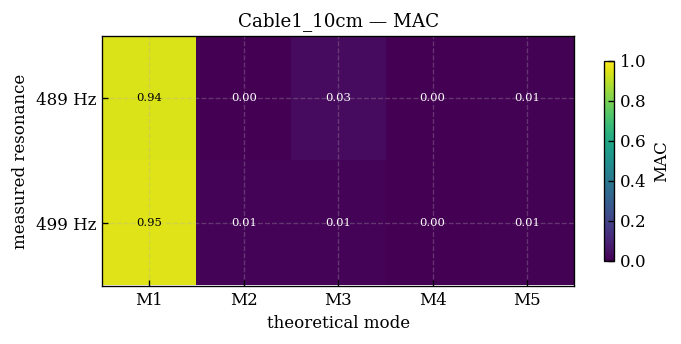

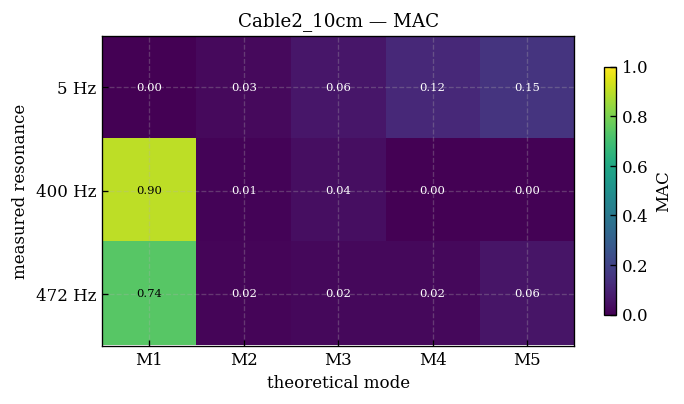

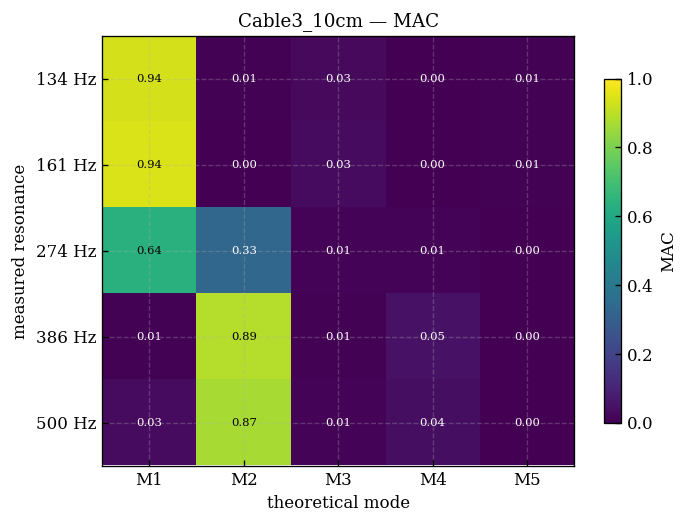

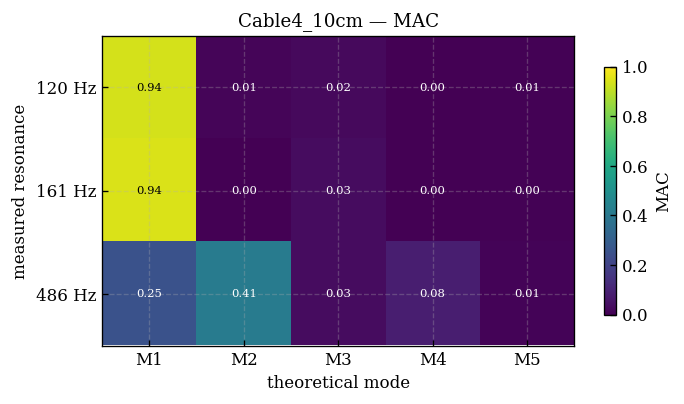

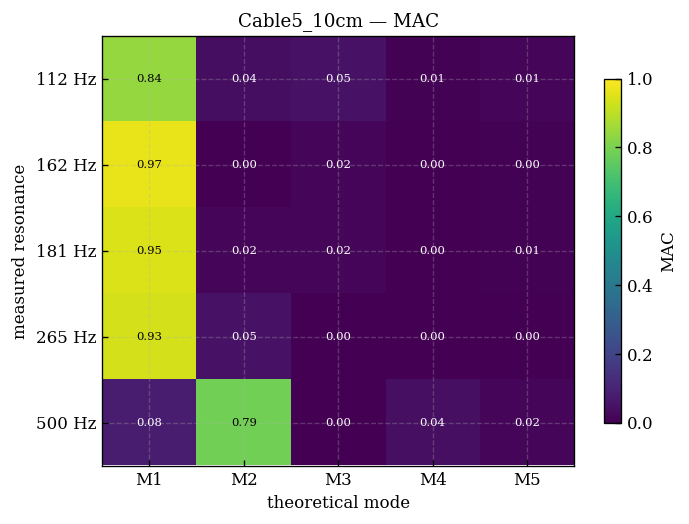

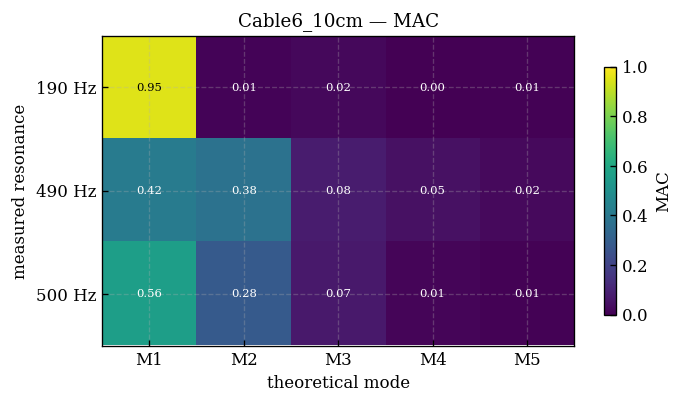

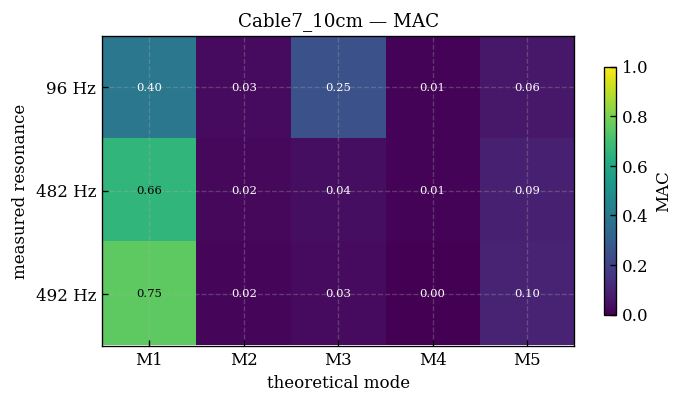

In [16]:
for cfg in DATASETS:
    if cfg['modal']['modes']:
        modal_plotting.plot_mac_heatmap(cfg)
        plt.show()

---
## § 5  Polarization summary

In [17]:
for cfg in DATASETS:
    print(f"{cfg['label']}:")
    for m in cfg['modal']['modes']:
        print(f"   {m['f_n']:6.1f} Hz | mode {m['mode_order']} "
              f"(MAC {m['mac']:.2f}) | {m['dom_pol']:<10} | "
              f"axis ratio {m['dom_axis_ratio']:.3f} | "
              f"hand {m['dom_handedness']:+d}")

Cable1_10cm:
    489.0 Hz | mode 1 (MAC 0.94) | linear     | axis ratio 0.091 | hand -1
    499.0 Hz | mode 1 (MAC 0.95) | elliptical | axis ratio 0.324 | hand -1
Cable2_10cm:
      5.0 Hz | mode 5 (MAC 0.15) | linear     | axis ratio 0.080 | hand -1
    400.0 Hz | mode 1 (MAC 0.90) | elliptical | axis ratio 0.306 | hand -1
    472.0 Hz | mode 1 (MAC 0.74) | linear     | axis ratio 0.093 | hand -1
Cable3_10cm:
    134.0 Hz | mode 1 (MAC 0.94) | linear     | axis ratio 0.013 | hand +1
    161.0 Hz | mode 1 (MAC 0.94) | linear     | axis ratio 0.039 | hand -1
    273.5 Hz | mode 1 (MAC 0.64) | linear     | axis ratio 0.051 | hand +1
    386.0 Hz | mode 2 (MAC 0.89) | linear     | axis ratio 0.052 | hand +1
    499.5 Hz | mode 2 (MAC 0.87) | linear     | axis ratio 0.030 | hand -1
Cable4_10cm:
    120.0 Hz | mode 1 (MAC 0.94) | linear     | axis ratio 0.079 | hand -1
    161.0 Hz | mode 1 (MAC 0.94) | linear     | axis ratio 0.010 | hand -1
    486.0 Hz | mode 2 (MAC 0.41) | elliptical | 

---
## § 6  Deep-dive & cross-dataset views

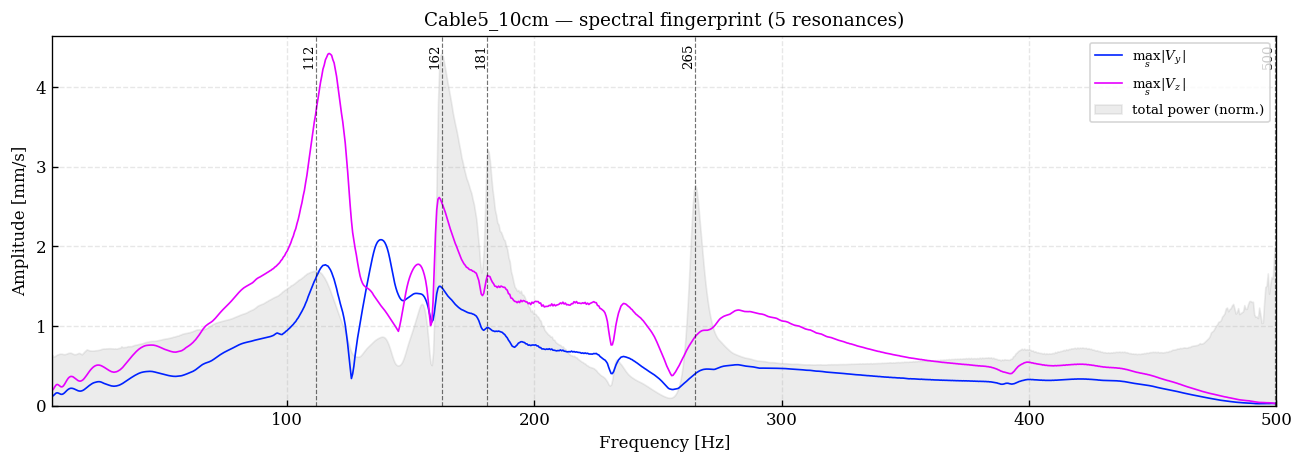

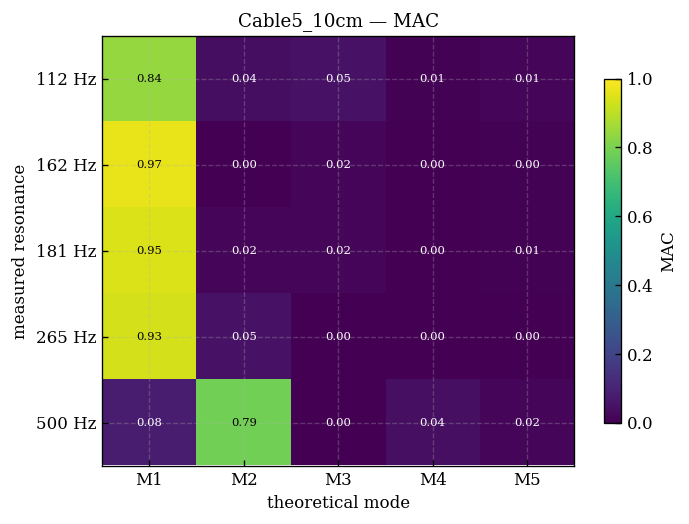

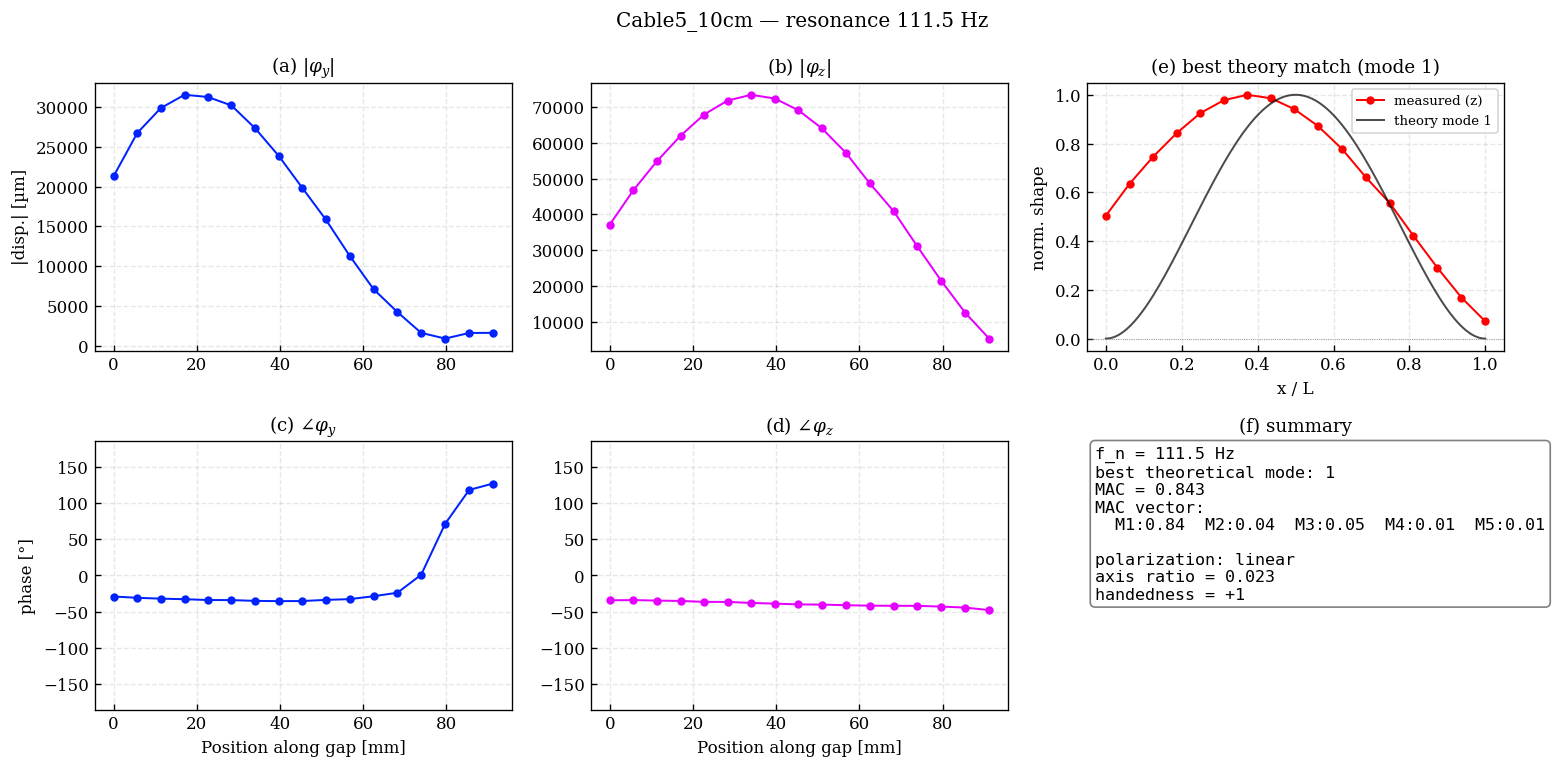

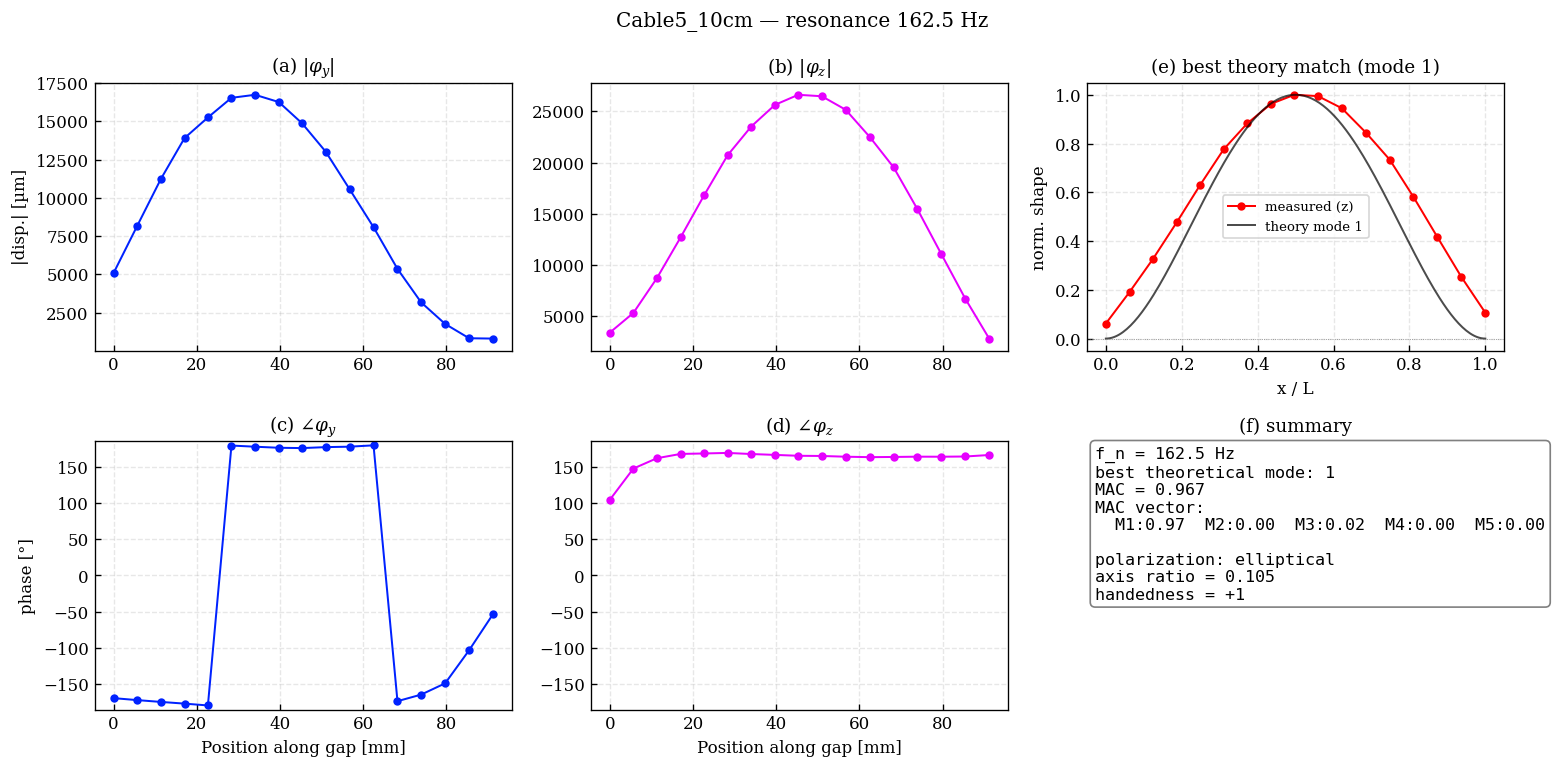

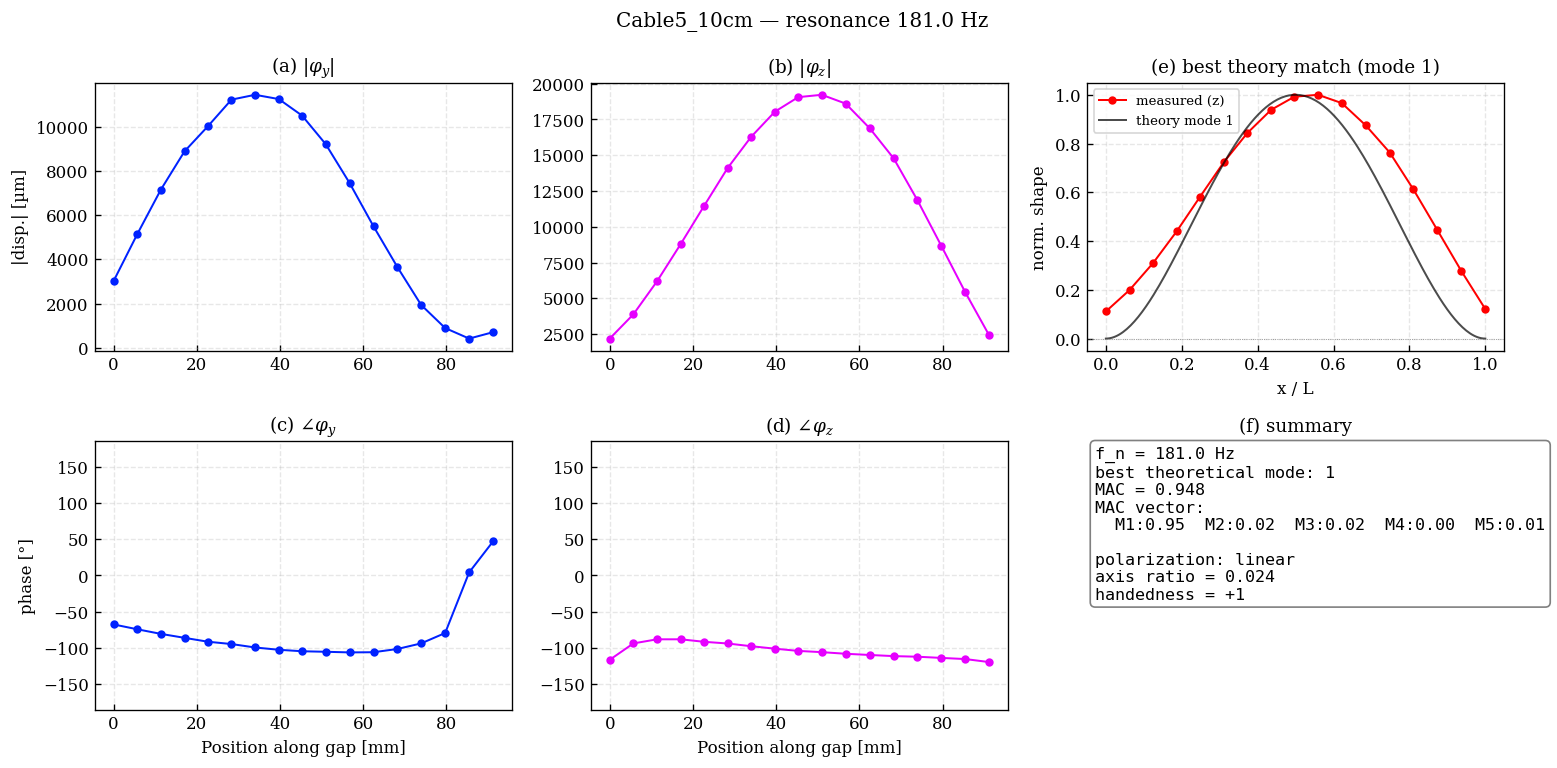

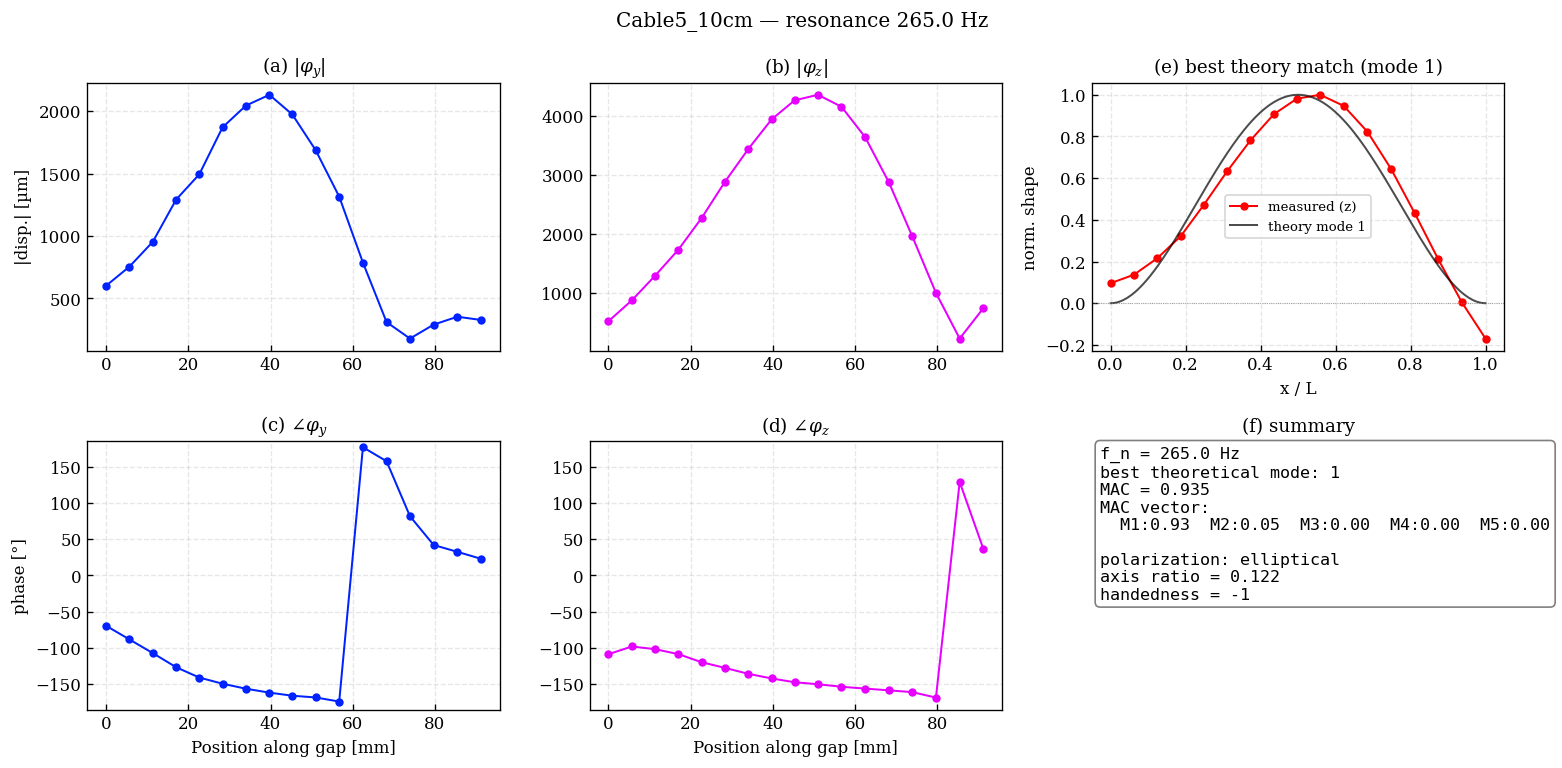

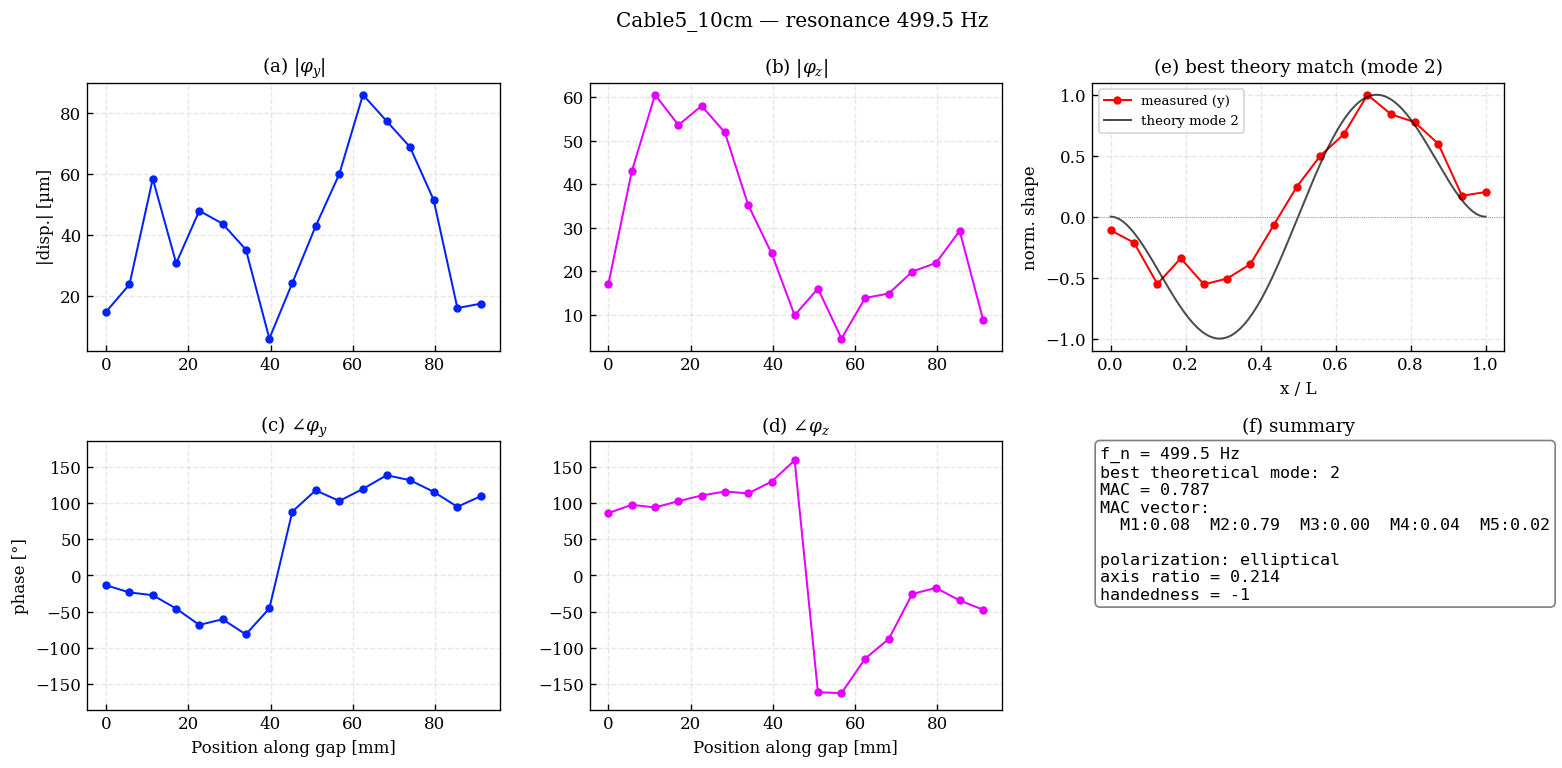

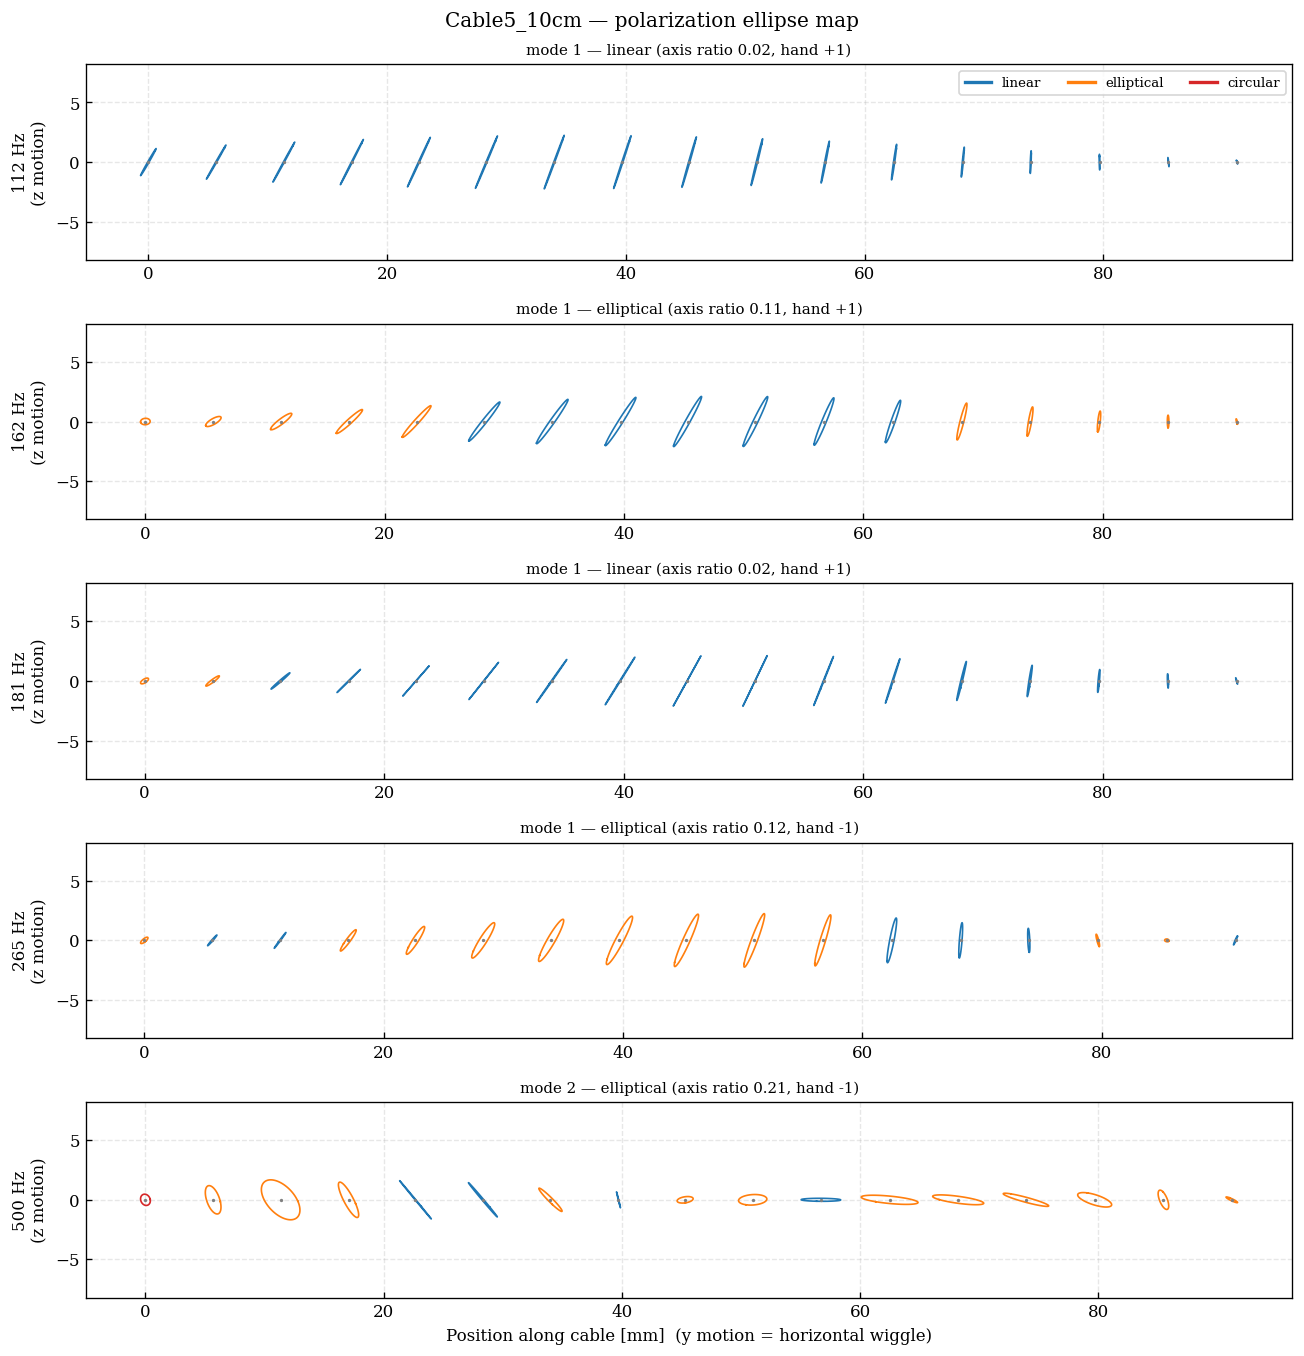

In [19]:
DEEP_DIVE_LABEL = DATASETS[4]['label']
cfg = next(c for c in DATASETS if c['label'] == DEEP_DIVE_LABEL)
modal_plotting.deep_dive(cfg);

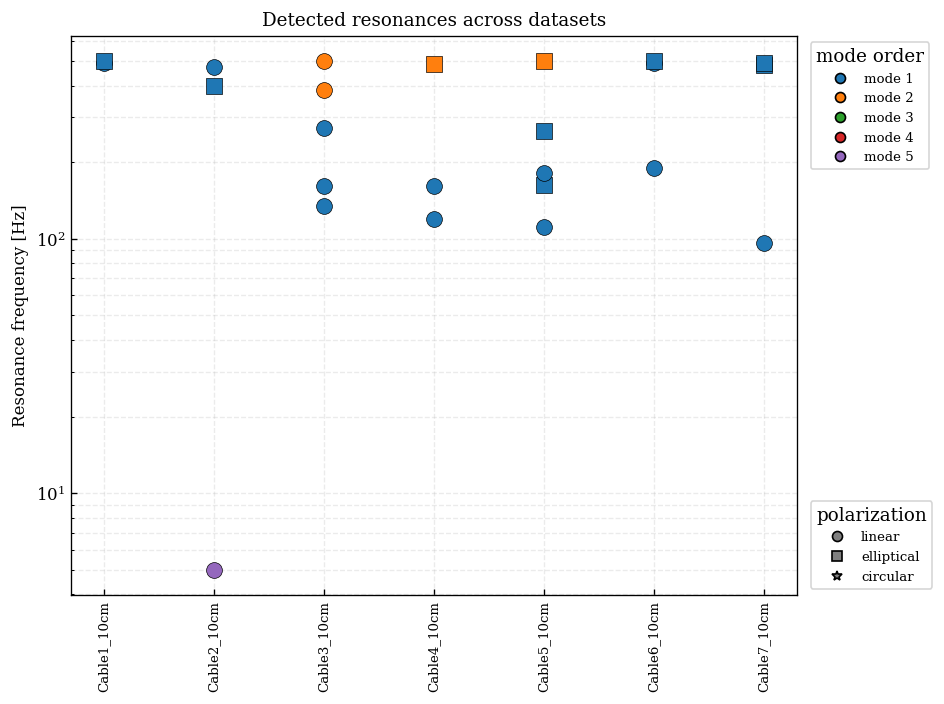

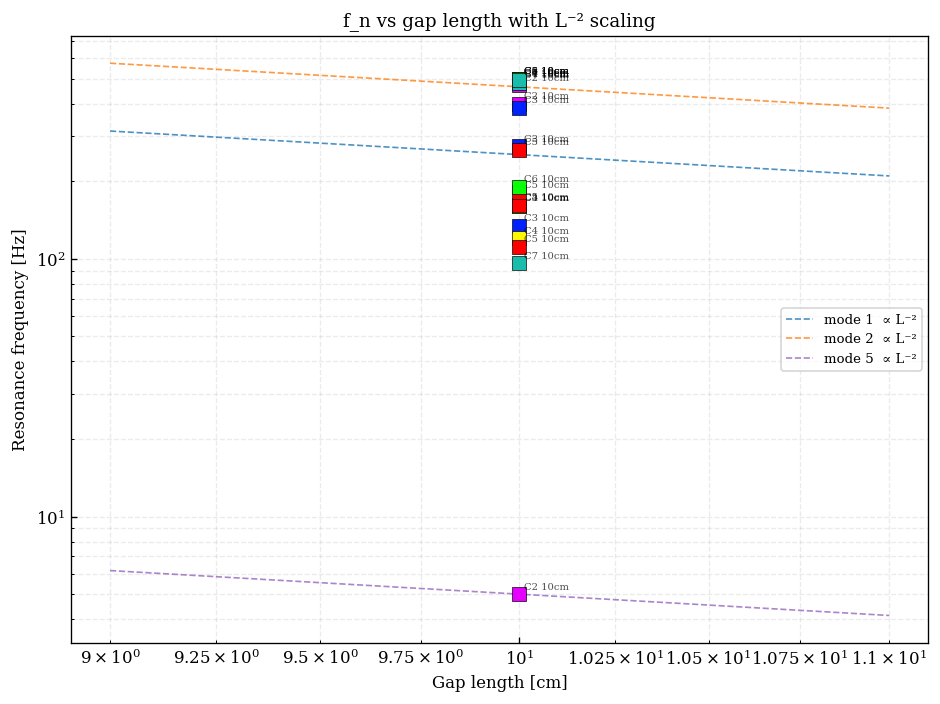

In [20]:
modal_plotting.plot_mode_frequency_chart(DATASETS)
plt.show()
modal_plotting.plot_fn_vs_gap(DATASETS)
plt.show()

In [21]:
modal_plotting.modal_dashboard(DATASETS);

---
## § 7  Export

In [22]:
summary = modal_plotting.build_summary_table(DATASETS)
summary.to_csv(config.RESULTS_DIR / 'modal_summary.csv', index=False)
print(f"{len(summary)} detected modes -> results/modal_summary.csv")

export.export_results(
    'modal_summary',
    meta=dict(f_min=F_MIN, f_max=F_MAX, prominence=PEAK_PROMINENCE,
              min_spacing_hz=MIN_SPACING_HZ,
              fingerprint_method=FINGERPRINT_METHOD, smooth_hz=SMOOTH_HZ,
              normalize_by_input=NORMALIZE_BY_INPUT),
    labels=[str(x) for x in summary['dataset']],
    f_n=summary['f_n'].to_numpy(dtype=float),
    mode_order=summary['mode_order'].to_numpy(dtype=float),
    mac=summary['MAC'].to_numpy(dtype=float),
)
summary

24 detected modes -> results/modal_summary.csv
exported modal_summary.npz: labels(24,), f_n(24,), mode_order(24,), mac(24,)


,dataset,cable,gap_m,f_n,mode_order,MAC,polarization_type,axis_ratio,handedness
0,Cable1_10cm,Cable1,0.1,489.0,1,0.942,linear,0.091,-1
1,Cable1_10cm,Cable1,0.1,499.0,1,0.952,elliptical,0.324,-1
2,Cable2_10cm,Cable2,0.1,5.0,5,0.150,linear,0.080,-1
3,Cable2_10cm,Cable2,0.1,400.0,1,0.898,elliptical,0.306,-1
4,Cable2_10cm,Cable2,0.1,472.0,1,0.742,linear,0.093,-1
5,Cable3_10cm,Cable3,0.1,134.0,1,0.937,linear,0.013,1
6,Cable3_10cm,Cable3,0.1,161.0,1,0.945,linear,0.039,-1
7,Cable3_10cm,Cable3,0.1,273.5,1,0.636,linear,0.051,1
8,Cable3_10cm,Cable3,0.1,386.0,2,0.889,linear,0.052,1
9,Cable3_10cm,Cable3,0.1,499.5,2,0.871,linear,0.030,-1
